In [19]:
!pip -q install scikit-learn xgboost

In [20]:
!pip -q install scikit-learn

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_squared_error
from sklearn.svm import LinearSVC
from xgboost import XGBRegressor

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# Paths
BASE = "/content/drive/MyDrive/emperical/dataset New"
TRAIN_PATH = f"{BASE}/training_full_features.csv"
VALID_PATH = f"{BASE}/valid_full_features.csv"
TEST_PATH  = f"{BASE}/test_full_features.csv"

df_train = pd.read_csv(TRAIN_PATH)
df_valid = pd.read_csv(VALID_PATH)
df_test  = pd.read_csv(TEST_PATH)

print("Train shape:", df_train.shape)
print("Valid shape:", df_valid.shape)
print("Test shape:",  df_test.shape)

Train shape: (12976, 37)
Valid shape: (4218, 14)
Test shape: (4254, 14)


In [22]:
# We work only with Essay Set 1 (scores 2–12)
df_train1 = df_train[df_train["essay_set"] == 1].copy()
df_valid1 = df_valid[df_valid["essay_set"] == 1].copy()
df_test1  = df_test[df_test["essay_set"] == 1].copy()

print("Train Set 1:", df_train1.shape)
print("Valid Set 1:", df_valid1.shape)
print("Test  Set 1:", df_test1.shape)

# Target labels (training only)
y = df_train1["domain1_score"].astype(int).values

# Feature columns – all handcrafted features
feature_cols = [
    "Word Count",
    "Sentence Count",
    "Avg. Sentence Length",
    "Spelling Error Count",
    "Grammar Error Count",
    "Type-Token Ratio (TTR)",
    "Stopword Ratio",
    "Use of Academic Words",
    "Similarity",
]

# Handle possible NaNs in Grammar Error Count
for df_ in (df_train1, df_valid1, df_test1):
    if "Grammar Error Count" in df_.columns:
        df_["Grammar Error Count"] = df_["Grammar Error Count"].fillna(0)

X_train = df_train1[feature_cols].values
X_valid = df_valid1[feature_cols].values
X_test  = df_test1[feature_cols].values

print("X_train:", X_train.shape, "  y:", y.shape)
print("Score range:", y.min(), "to", y.max())

Train Set 1: (1783, 37)
Valid Set 1: (589, 14)
Test  Set 1: (594, 14)
X_train: (1783, 9)   y: (1783,)
Score range: 2 to 12


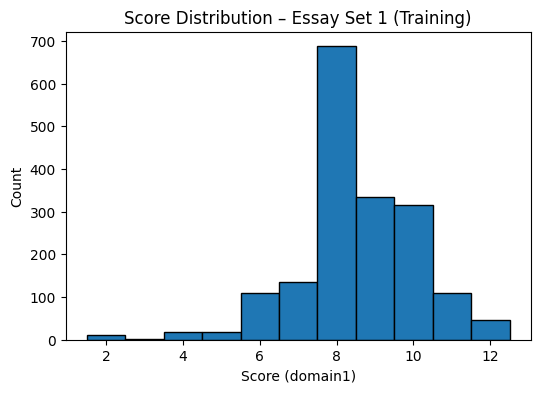

In [23]:
# Histogram of scores in training set
plt.figure(figsize=(6,4))
plt.hist(y, bins=np.arange(y.min()-0.5, y.max()+1.5, 1), edgecolor="black")
plt.xlabel("Score (domain1)")
plt.ylabel("Count")
plt.title("Score Distribution – Essay Set 1 (Training)")
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


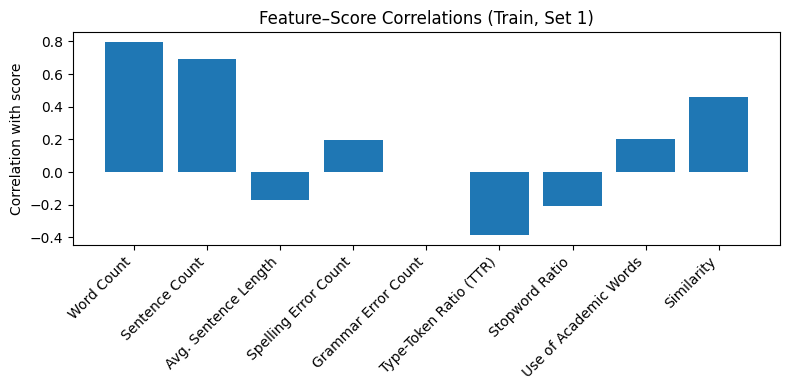

In [24]:
# Simple correlation of each feature with score (Pearson)
corrs = []
for col in feature_cols:
    corrs.append(np.corrcoef(df_train1[col], y)[0,1])

plt.figure(figsize=(8,4))
plt.bar(feature_cols, corrs)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Correlation with score")
plt.title("Feature–Score Correlations (Train, Set 1)")
plt.tight_layout()
plt.show()

In [25]:
# Classification models (predict discrete scores 2..12 directly)
clf_models = {
    "LogisticRegression_all": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            multi_class="multinomial",
            max_iter=500,
            solver="lbfgs",
            n_jobs=-1
        )),
    ]),

    "RandomForestClassifier_all": RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    # NEW: Linear SVM classifier using all features
    "LinearSVM_all": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LinearSVC(
            C=1.0,
            class_weight="balanced",  # helps with rare scores
            random_state=42
        )),
    ]),
}

In [26]:
def clip_round_scores(pred):
    """Round to nearest int and clip to [2, 12]."""
    pred_rounded = np.rint(pred).astype(int)
    return np.clip(pred_rounded, 2, 12)

def evaluate_cv_classifier(name, model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs, f1s, qwks = [], [], []

    print(f"\n=== CV – {name} (Classification) ===")
    for i, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        acc = accuracy_score(y_val, y_pred)
        f1  = f1_score(y_val, y_pred, average="macro")
        qwk = cohen_kappa_score(y_val, y_pred, weights="quadratic")

        accs.append(acc); f1s.append(f1); qwks.append(qwk)
        print(f"Fold {i}: Acc={acc:.3f}, F1={f1:.3f}, QWK={qwk:.3f}")

    print(f"Mean Acc={np.mean(accs):.3f} ± {np.std(accs):.3f}")
    print(f"Mean F1 ={np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    print(f"Mean QWK={np.mean(qwks):.3f} ± {np.std(qwks):.3f}")
    return np.mean(qwks)


def evaluate_cv_regressor(name, model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    accs, f1s, qwks, rmses = [], [], [], []

    print(f"\n=== CV – {name} (Regression, rounded to 2..12) ===")
    for i, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_cont = model.predict(X_val)
        y_pred = clip_round_scores(y_pred_cont)

        acc = accuracy_score(y_val, y_pred)
        f1  = f1_score(y_val, y_pred, average="macro")
        qwk = cohen_kappa_score(y_val, y_pred, weights="quadratic")
        rmse = np.sqrt(mean_squared_error(y_val, y_pred_cont))

        accs.append(acc); f1s.append(f1); qwks.append(qwk); rmses.append(rmse)
        print(f"Fold {i}: Acc={acc:.3f}, F1={f1:.3f}, QWK={qwk:.3f}, RMSE={rmse:.3f}")

    print(f"Mean Acc={np.mean(accs):.3f} ± {np.std(accs):.3f}")
    print(f"Mean F1 ={np.mean(f1s):.3f} ± {np.std(f1s):.3f}")
    print(f"Mean QWK={np.mean(qwks):.3f} ± {np.std(qwks):.3f}")
    print(f"Mean RMSE={np.mean(rmses):.3f} ± {np.std(rmses):.3f}")
    return np.mean(qwks)

In [27]:
# Regression models (predict continuous, then round/clip to 2..12)
reg_models = {
    "RandomForestRegressor_all": RandomForestRegressor(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "GradientBoostingRegressor_all": GradientBoostingRegressor(
        learning_rate=0.05,
        n_estimators=400,
        max_depth=3,
        random_state=42
    ),

    # NEW: XGBoost regressor using all features
    "XGBRegressor_all": XGBRegressor(
        n_estimators=600,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),
}

In [28]:
# Run CV for all models and pick the best by mean QWK
best_model = None
best_name = None
best_qwk = -1.0
best_type = None  # "clf" or "reg"

for name, model in clf_models.items():
    mean_qwk = evaluate_cv_classifier(name, model, X_train, y, n_splits=5)
    if mean_qwk > best_qwk:
        best_qwk, best_name, best_model, best_type = mean_qwk, name, model, "clf"

for name, model in reg_models.items():
    mean_qwk = evaluate_cv_regressor(name, model, X_train, y, n_splits=5)
    if mean_qwk > best_qwk:
        best_qwk, best_name, best_model, best_type = mean_qwk, name, model, "reg"

print("\nBest model overall:")
print("  Name:", best_name)
print("  Type:", best_type)
print("  Mean CV QWK:", best_qwk)


=== CV – LogisticRegression_all (Classification) ===


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 1: Acc=0.543, F1=0.279, QWK=0.798


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Fold 2: Acc=0.543, F1=0.222, QWK=0.805
Fold 3: Acc=0.518, F1=0.314, QWK=0.784


...

Fold 1: Acc=0.496, F1=0.446, QWK=0.847, RMSE=0.781
Fold 2: Acc=0.574, F1=0.409, QWK=0.869, RMSE=0.730
Fold 3: Acc=0.521, F1=0.448, QWK=0.832, RMSE=0.796
Fold 4: Acc=0.449, F1=0.352, QWK=0.800, RMSE=0.864
Fold 5: Acc=0.489, F1=0.447, QWK=0.806, RMSE=0.851
Mean Acc=0.506 ± 0.041
Mean F1 =0.421 ± 0.037
Mean QWK=0.831 ± 0.026
Mean RMSE=0.804 ± 0.049

=== CV – GradientBoostingRegressor_all (Regression, rounded to 2..12) ===


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: Acc=0.493, F1=0.400, QWK=0.830, RMSE=0.809
Fold 2: Acc=0.549, F1=0.426, QWK=0.850, RMSE=0.742
Fold 3: Acc=0.473, F1=0.409, QWK=0.806, RMSE=0.825
Fold 4: Acc=0.472, F1=0.360, QWK=0.803, RMSE=0.875
Fold 5: Acc=0.503, F1=0.453, QWK=0.806, RMSE=0.847
Mean Acc=0.498 ± 0.028
Mean F1 =0.410 ± 0.031
Mean QWK=0.819 ± 0.018
Mean RMSE=0.819 ± 0.045

=== CV – XGBRegressor_all (Regression, rounded to 2..12) ===


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Fold 1: Acc=0.490, F1=0.352, QWK=0.817, RMSE=0.838
Fold 2: Acc=0.546, F1=0.328, QWK=0.854, RMSE=0.743
Fold 3: Acc=0.476, F1=0.349, QWK=0.804, RMSE=0.847
Fold 4: Acc=0.455, F1=0.380, QWK=0.790, RMSE=0.879
Fold 5: Acc=0.478, F1=0.457, QWK=0.804, RMSE=0.874
Mean Acc=0.489 ± 0.031
Mean F1 =0.373 ± 0.045
Mean QWK=0.814 ± 0.022
Mean RMSE=0.836 ± 0.049

Best model overall:
  Name: RandomForestRegressor_all
  Type: reg
  Mean CV QWK: 0.8307019760698882


In [35]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, mean_squared_error

# Re-run CV, but this time collect metrics into a table
rows = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in clf_models.items():
    accs, f1s, qwks = [], [], []
    for tr_idx, val_idx in skf.split(X_train, y):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val)

        accs.append(accuracy_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred, average="macro"))
        qwks.append(cohen_kappa_score(y_val, y_pred, weights="quadratic"))

    rows.append({
        "Model": name,
        "Type": "Classifier",
        "Mean Accuracy": np.mean(accs),
        "Std Accuracy": np.std(accs),
        "Mean Macro F1": np.mean(f1s),
        "Std Macro F1": np.std(f1s),
        "Mean QWK": np.mean(qwks),
        "Std QWK": np.std(qwks),
        "Mean RMSE": np.nan,  # not relevant for pure classifiers
        "Std RMSE": np.nan,
    })

for name, model in reg_models.items():
    accs, f1s, qwks, rmses = [], [], [], []
    for tr_idx, val_idx in skf.split(X_train, y):
        X_tr, X_val = X_train[tr_idx], X_train[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        model.fit(X_tr, y_tr)
        y_pred_cont = model.predict(X_val)
        y_pred = clip_round_scores(y_pred_cont)

        accs.append(accuracy_score(y_val, y_pred))
        f1s.append(f1_score(y_val, y_pred, average="macro"))
        qwks.append(cohen_kappa_score(y_val, y_pred, weights="quadratic"))
        rmses.append(np.sqrt(mean_squared_error(y_val, y_pred_cont)))

    rows.append({
        "Model": name,
        "Type": "Regressor (rounded)",
        "Mean Accuracy": np.mean(accs),
        "Std Accuracy": np.std(accs),
        "Mean Macro F1": np.mean(f1s),
        "Std Macro F1": np.std(f1s),
        "Mean QWK": np.mean(qwks),
        "Std QWK": np.std(qwks),
        "Mean RMSE": np.mean(rmses),
        "Std RMSE": np.std(rmses),
    })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values("Mean QWK", ascending=False)

results_df

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default 

,Model,Type,Mean Accuracy,Std Accuracy,Mean Macro F1,Std Macro F1,Mean QWK,Std QWK,Mean RMSE,Std RMSE
3,RandomForestRegressor_all,Regressor (rounded),0.505848,0.041185,0.420512,0.037176,0.830702,0.025780,0.804331,0.048690
4,GradientBoostingRegressor_all,Regressor (rounded),0.498025,0.028062,0.409633,0.030912,0.819019,0.018218,0.819394,0.044756
5,XGBRegressor_all,Regressor (rounded),0.489038,0.030735,0.373325,0.044797,0.813580,0.021905,0.836244,0.048990
1,RandomForestClassifier_all,Classifier,0.508115,0.020956,0.347654,0.029643,0.793343,0.024264,NaN,NaN
0,LogisticRegression_all,Classifier,0.526065,0.018391,0.290993,0.038806,0.780586,0.020116,NaN,NaN
2,LinearSVM_all,Classifier,0.427344,0.026639,0.285319,0.046138,0.769264,0.027401,NaN,NaN


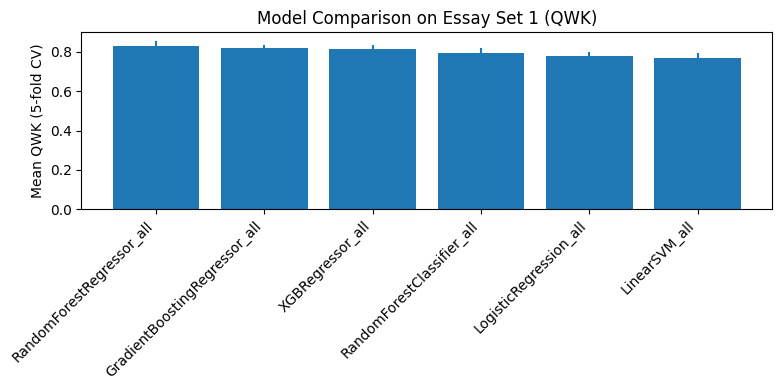

In [36]:
import matplotlib.pyplot as plt

# Use the results_df from above
plt.figure(figsize=(8,4))
plt.bar(results_df["Model"], results_df["Mean QWK"])
plt.errorbar(
    x=np.arange(len(results_df)),
    y=results_df["Mean QWK"],
    yerr=results_df["Std QWK"],
    fmt="none"
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean QWK (5-fold CV)")
plt.title("Model Comparison on Essay Set 1 (QWK)")
plt.tight_layout()
plt.show()

In [37]:
from sklearn.model_selection import train_test_split

# Single 20% hold-out just for visualization
X_tr_vis, X_val_vis, y_tr_vis, y_val_vis = train_test_split(
    X_train, y, test_size=0.2, random_state=123
)

# Refit the best model on this 80%
best_model.fit(X_tr_vis, y_tr_vis)

if best_type == "clf":
    y_pred_vis = best_model.predict(X_val_vis)
else:
    y_pred_cont_vis = best_model.predict(X_val_vis)
    y_pred_vis = clip_round_scores(y_pred_cont_vis)

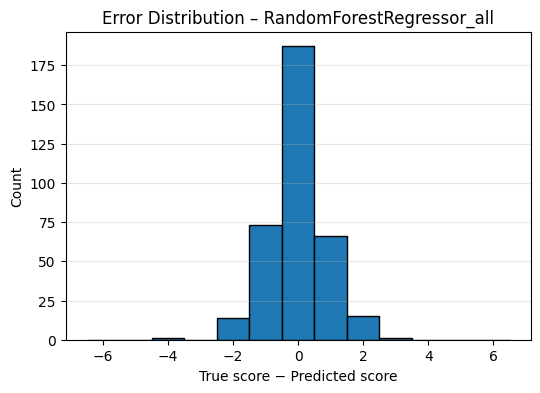

In [38]:
errors = y_val_vis - y_pred_vis

plt.figure(figsize=(6,4))
plt.hist(errors, bins=np.arange(-6.5, 6.6, 1), edgecolor="black")
plt.xlabel("True score − Predicted score")
plt.ylabel("Count")
plt.title(f"Error Distribution – {best_name}")
plt.grid(axis="y", alpha=0.3)
plt.show()

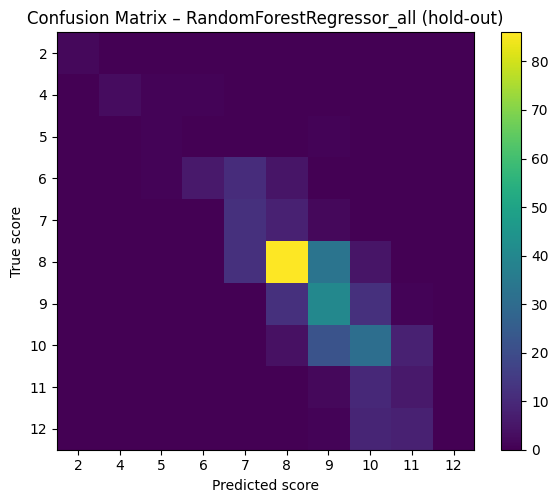

In [39]:
from sklearn.metrics import confusion_matrix

labels = sorted(np.unique(y_val_vis))
cm = confusion_matrix(y_val_vis, y_pred_vis, labels=labels)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.xlabel("Predicted score")
plt.ylabel("True score")
plt.title(f"Confusion Matrix – {best_name} (hold-out)")
plt.tight_layout()
plt.show()

In [29]:
from sklearn.model_selection import train_test_split

# 80/20 internal hold-out split for a single "final" evaluation
# (no stratify, because at least one class has only 1 sample)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y, test_size=0.2, random_state=123
)

# Refit the chosen best model
best_model.fit(X_tr, y_tr)

if best_type == "clf":
    y_pred_val = best_model.predict(X_val)
else:
    y_pred_val_cont = best_model.predict(X_val)
    y_pred_val = clip_round_scores(y_pred_val_cont)

acc = accuracy_score(y_val, y_pred_val)
f1  = f1_score(y_val, y_pred_val, average="macro")
qwk = cohen_kappa_score(y_val, y_pred_val, weights="quadratic")

print("\nFinal hold-out (20%) evaluation with best model:")
print(f"Accuracy: {acc:.3f}")
print(f"Macro F1: {f1:.3f}")
print(f"QWK:      {qwk:.3f}")


Final hold-out (20%) evaluation with best model:
Accuracy: 0.524
Macro F1: 0.438
QWK:      0.828


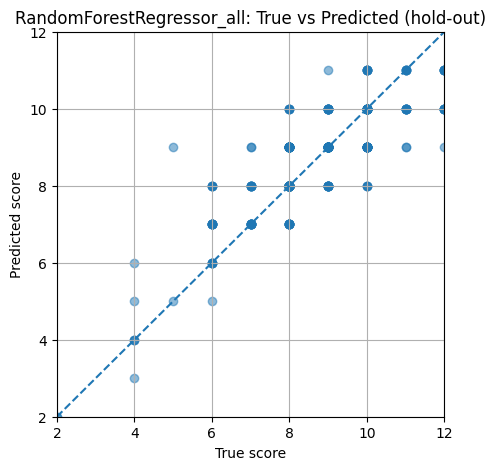

In [30]:
plt.figure(figsize=(5,5))
plt.scatter(y_val, y_pred_val, alpha=0.5)
plt.plot([2,12], [2,12], linestyle="--")
plt.xlabel("True score")
plt.ylabel("Predicted score")
plt.title(f"{best_name}: True vs Predicted (hold-out)")
plt.xlim(2,12); plt.ylim(2,12)
plt.grid(True)
plt.show()

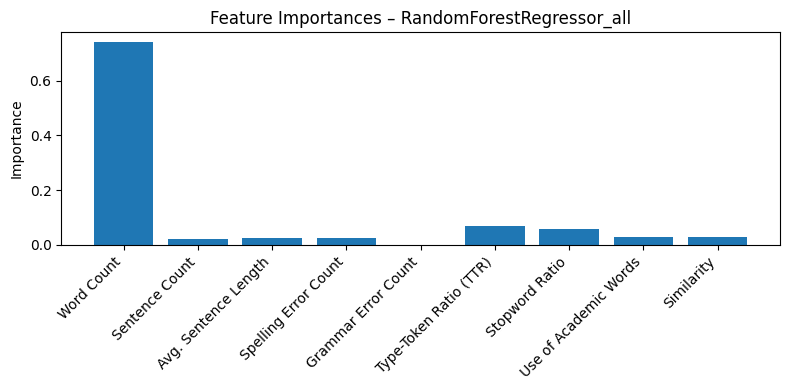

In [31]:
if "RandomForest" in best_name:
    # For pipelines, get the RF step; for pure RF it's the model itself
    rf = best_model
    if isinstance(best_model, Pipeline):
        for step_name, step_obj in best_model.named_steps.items():
            if isinstance(step_obj, (RandomForestClassifier, RandomForestRegressor)):
                rf = step_obj
                break

    importances = rf.feature_importances_
    plt.figure(figsize=(8,4))
    plt.bar(feature_cols, importances)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Importance")
    plt.title(f"Feature Importances – {best_name}")
    plt.tight_layout()
    plt.show()

In [32]:
# Fit best model on ALL training data (Set 1)
best_model.fit(X_train, y)
print("\nBest model refit on ALL training data for Set 1.")


Best model refit on ALL training data for Set 1.


In [33]:
def evaluate_or_predict_on_split(df_split, X_split, split_name):
    if "domain1_score" in df_split.columns:
        y_true = df_split["domain1_score"].astype(int).values
        if best_type == "clf":
            y_pred = best_model.predict(X_split)
        else:
            y_pred_cont = best_model.predict(X_split)
            y_pred = clip_round_scores(y_pred_cont)

        acc = accuracy_score(y_true, y_pred)
        f1  = f1_score(y_true, y_pred, average="macro")
        qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

        print(f"\n{split_name} metrics (using {best_name}):")
        print(f"Accuracy: {acc:.3f}")
        print(f"Macro F1: {f1:.3f}")
        print(f"QWK:      {qwk:.3f}")
        return y_pred
    else:
        # no labels – just predictions
        if best_type == "clf":
            y_pred = best_model.predict(X_split)
        else:
            y_pred_cont = best_model.predict(X_split)
            y_pred = clip_round_scores(y_pred_cont)

        print(f"\n{split_name}: no domain1_score column; only predictions produced.")
        return y_pred

# VALID
valid_pred = evaluate_or_predict_on_split(df_valid1, X_valid, "VALID Set 1")

# TEST
test_pred  = evaluate_or_predict_on_split(df_test1,  X_test,  "TEST Set 1")


VALID Set 1: no domain1_score column; only predictions produced.

TEST Set 1: no domain1_score column; only predictions produced.


In [34]:
# Save predictions for VALID and TEST
valid_out = df_valid1[["essay_id", "essay_set"]].copy()
valid_out["predicted_domain1_score"] = valid_pred

test_out = df_test1[["essay_id", "essay_set"]].copy()
test_out["predicted_domain1_score"] = test_pred

valid_out.to_csv(f"{BASE}/valid_predictions_set1_best.csv", index=False)
test_out.to_csv(f"{BASE}/test_predictions_set1_best.csv", index=False)

print("\nSaved VALID predictions to:", f"{BASE}/valid_predictions_set1_best.csv")
print("Saved TEST predictions to:",  f"{BASE}/test_predictions_set1_best.csv")


Saved VALID predictions to: /content/drive/MyDrive/emperical/dataset New/valid_predictions_set1_best.csv
Saved TEST predictions to: /content/drive/MyDrive/emperical/dataset New/test_predictions_set1_best.csv


In [40]:
# Create (or overwrite) a README.md file in your project folder on Drive

readme_path = "/content/drive/MyDrive/emperical/README.md"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write("# Automated Essay Scoring – Empirical Project\n\n")
    f.write("TODO: Paste the full README content here.\n")

print("README.md created at:", readme_path)

README.md created at: /content/drive/MyDrive/emperical/README.md
